In [1]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
import random
from tensorflow.keras import backend as K
import gc

# 1. Definir rutas relativas
BASE_PATH = "PH2Dataset"
IMAGES_DIR = os.path.join(BASE_PATH, "PH2 Dataset images")
XLSX_PATH = os.path.join(BASE_PATH, "PH2_dataset.xlsx")

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42

# 2. Leer el archivo Excel (saltando las 12 filas de leyendas)
df = pd.read_excel(XLSX_PATH, skiprows=12)

# Limpiar nombres de columnas para evitar espacios ocultos
df.columns = df.columns.str.strip()

# 3. Nueva lógica de mapeo basada en las columnas de "X"
labels = []
filepaths = []

for idx, row in df.iterrows():
    lesion_id = str(row['Image Name']).strip()
    
    # Procesar solo filas que contengan un ID válido de imagen (IMDxxx)
    if lesion_id.startswith("IMD"):
        img_path = os.path.join(IMAGES_DIR, lesion_id, f"{lesion_id}_Dermoscopic_Image", f"{lesion_id}.bmp")
        
        if os.path.exists(img_path):
            # Comprobamos en cuál columna pusieron la 'X' (sin importar mayúsculas/minúsculas)
            is_common = str(row['Common Nevus']).strip().upper() == 'X'
            is_atypical = str(row['Atypical Nevus']).strip().upper() == 'X'
            is_melanoma = str(row['Melanoma']).strip().upper() == 'X'
            
            if is_melanoma:
                label = 2
            elif is_atypical:
                label = 1
            elif is_common:
                label = 0
            else:
                # Caso extremo: si no tiene 'X', usamos un fallback seguro por exclusión
                label = 0 
                
            filepaths.append(img_path)
            labels.append(label)

filepaths = np.array(filepaths)
labels = np.array(labels)

print(f"\nMuestras procesadas exitosamente desde el Excel: {len(filepaths)}")
for c_name, c_idx in [('Common Nevi', 0), ('Atypical Nevi', 1), ('Melanoma', 2)]:
    print(f" - {c_name}: {np.sum(labels == c_idx)} imágenes")

# 4. División Estratificada (80% Train, 20% Val)
train_files, val_files, train_labels, val_labels = train_test_split(
    filepaths, labels, 
    test_size=0.2, 
    stratify=labels, 
    random_state=SEED
)

# 5. Pipeline optimizado con tf.data
def parse_image(filename, label):
    image_string = tf.io.read_file(filename)
    image = tf.io.decode_bmp(image_string, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = image / 255.0
    return image, label

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomContrast(0.15)
])

def configure_for_performance(ds, shuffle=False, augment=False):
    ds = ds.cache()
    if shuffle:
        ds = ds.shuffle(buffer_size=len(train_files), seed=SEED)
    ds = ds.batch(BATCH_SIZE)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), 
                    num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(buffer_size=tf.data.AUTOTUNE)

train_ds = tf.data.Dataset.from_tensor_slices((train_files, train_labels)).map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = configure_for_performance(train_ds, shuffle=True, augment=True)

val_ds = tf.data.Dataset.from_tensor_slices((val_files, val_labels)).map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = configure_for_performance(val_ds, shuffle=False, augment=False)

print("\n[OK] Datasets de TensorFlow corregidos y listos.")

I0000 00:00:1779055294.080936   16331 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.



Muestras procesadas exitosamente desde el Excel: 200
 - Common Nevi: 80 imágenes
 - Atypical Nevi: 80 imágenes
 - Melanoma: 40 imágenes


I0000 00:00:1779055296.207423   16331 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7496 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1080, pci bus id: 0000:01:00.0, compute capability: 6.1



[OK] Datasets de TensorFlow corregidos y listos.


In [2]:
def set_reproducibility(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_reproducibility(42)

# Modelado

## Primera ejecucion

In [3]:
K.clear_session()
gc.collect()
tf.compat.v1.reset_default_graph()
set_reproducibility(42)

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models

def create_model(input_shape=(224, 224, 3), num_classes=3):
    # 1. Cargar el modelo base sin la capa de clasificación superior
    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False, 
        weights='imagenet', 
        input_shape=input_shape
    )
    
    # 2. Congelar el modelo base
    base_model.trainable = False
    
    # 3. Construir la nueva estructura superior (Clasificador)
    inputs = layers.Input(shape=input_shape)
    
    # Importante: training=False mantiene BatchNormalization en modo inferencia
    x = base_model(inputs, training=False) 
    
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4, seed=SEED)(x) # Reduce el sobreajuste (overfitting)
    
    # Capa de salida: 3 neuronas con Softmax para obtener probabilidades
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs, outputs)
    return model

model = create_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,278 (16.70 MB)

 Trainable params: 328,707 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [5]:
# Calcular los pesos para equilibrar la importancia en el gradiente
# Total muestras (200) / (Num clases (3) * Muestras de la clase)
weight_for_common = 200.0 / (3 * 80)
weight_for_atypical = 200.0 / (3 * 80)
weight_for_melanoma = 200.0 / (3 * 40)

class_weights = {
    0: weight_for_common,
    1: weight_for_atypical,
    2: weight_for_melanoma
}

print("Pesos asignados por clase para compensar el desbalance:")
print(f" - Common Nevi (Clase 0): {weight_for_common:.2f}")
print(f" - Atypical Nevi (Clase 1): {weight_for_atypical:.2f}")
print(f" - Melanoma (Clase 2): {weight_for_melanoma:.2f}")

Pesos asignados por clase para compensar el desbalance:
 - Common Nevi (Clase 0): 0.83
 - Atypical Nevi (Clase 1): 0.83
 - Melanoma (Clase 2): 1.67


In [6]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks estratégicos
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,          # Espera 10 épocas sin mejora antes de parar
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,           # Reduce el LR a la quinta parte
        patience=4,           # Si en 4 épocas no mejora
        min_lr=1e-6
    )
]

In [7]:
EPOCHS = 50

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/50


I0000 00:00:1779055304.680908   16411 service.cc:153] XLA service 0x7f71780e91e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779055304.680935   16411 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce GTX 1080, Compute Capability 6.1 (Driver: 13.0.0; Runtime: 12.4.0; Toolkit: 12.5.0; DNN: 9.10.1)
I0000 00:00:1779055304.839027   16411 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779055306.094346   16411 cuda_dnn.cc:461] Loaded cuDNN version 91001
I0000 00:00:1779055306.358464   16411 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16256__.251
I0000 00:00:1779055316.219915   16411 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


10/10 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.3313 - loss: 1.1920 - val_accuracy: 0.2000 - val_loss: 1.2012 - learning_rate: 0.0010
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3250 - loss: 1.1907 - val_accuracy: 0.4000 - val_loss: 1.0857 - learning_rate: 0.0010
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3625 - loss: 1.1228 - val_accuracy: 0.4000 - val_loss: 1.0994 - learning_rate: 0.0010
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3375 - loss: 1.1324 - val_accuracy: 0.4000 - val_loss: 1.1034 - learning_rate: 0.0010
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4125 - loss: 1.1117 - val_accuracy: 0.4000 - val_loss: 1.1116 - learning_rate: 0.0010
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.2375 - loss: 1.1788 - val_accuracy: 0.2000 - val_loss: 1.1597 - learning_rate: 0.0010
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.2750 - loss: 1.1339 - val_accuracy: 0.200

In [9]:
import matplotlib.pyplot as plt

def plot_loss(history):
    # Crear una figura con dos subgráficos (Loss y Accuracy)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # 1. Gráfico de Pérdida (Loss)
    ax1.plot(history.history['loss'], label='Train Loss', color='royalblue', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Val Loss', color='orangered', linewidth=2)
    ax1.set_title('Curva de Pérdida (Loss)', fontsize=14)
    ax1.set_xlabel('Épocas', fontsize=12)
    ax1.set_ylabel('Pérdida', fontsize=12)
    ax1.legend(fontsize=11)
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    # 2. Gráfico de Precisión (Accuracy)
    ax2.plot(history.history['accuracy'], label='Train Accuracy', color='royalblue', linewidth=2)
    ax2.plot(history.history['val_accuracy'], label='Val Accuracy', color='orangered', linewidth=2)
    ax2.set_title('Curva de Precisión (Accuracy)', fontsize=14)
    ax2.set_xlabel('Épocas', fontsize=12)
    ax2.set_ylabel('Precisión', fontsize=12)
    ax2.legend(fontsize=11)
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

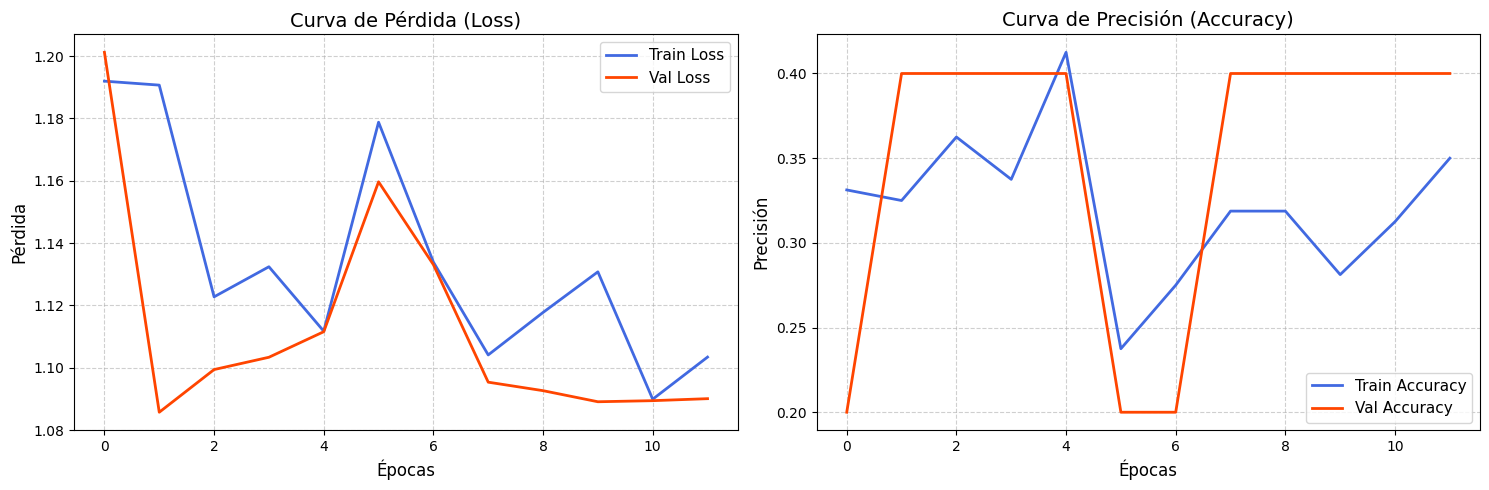

In [10]:
plot_loss(history)

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Extraer todas las imágenes y etiquetas reales del Dataset de validación de TensorFlow
y_true = []
y_pred_probs = []

for images, labels in val_ds:
    # Obtener probabilidades del modelo
    preds = model.predict(images, verbose=0)
    
    y_true.extend(labels.numpy())
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)

# Convertir las probabilidades (softmax) en la clase con el valor más alto (0, 1 o 2)
y_pred = np.argmax(y_pred_probs, axis=1)

print("¡Predicciones del set de validación calculadas con éxito!")

¡Predicciones del set de validación calculadas con éxito!


In [15]:
def plot_confusion_matriz(target_names, y_true, y_pred):
    
    # Calcular la matriz de confusión
    cm = confusion_matrix(y_true, y_pred)
    
    # Graficar usando Seaborn
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues', 
        xticklabels=target_names, 
        yticklabels=target_names,
        cbar=False,
        annot_kws={"size": 14, "weight": "bold"}
    )
    
    plt.title('Matriz de Confusión - Dataset PH2', fontsize=16, pad=15)
    plt.ylabel('Clase Real (Diagnóstico Médico)', fontsize=12)
    plt.xlabel('Clase Predicha por el Modelo', fontsize=12)
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)
    plt.tight_layout()
    plt.show()

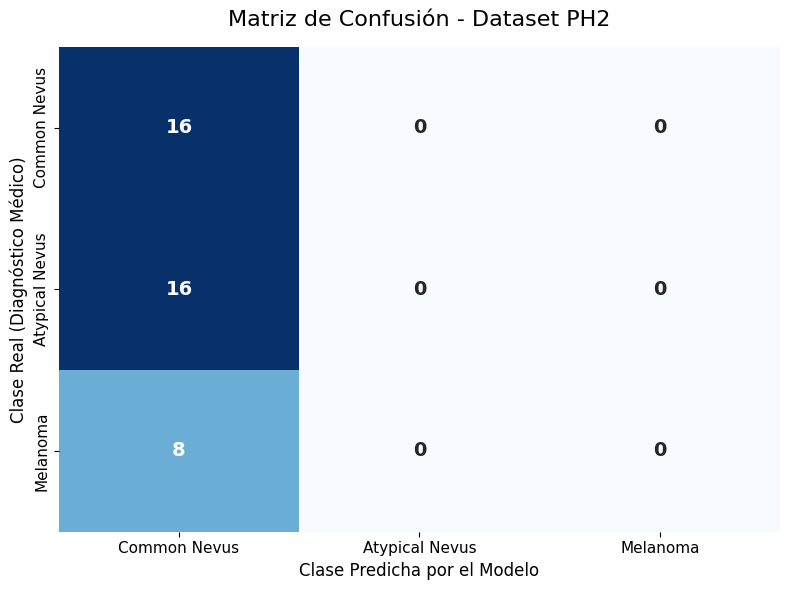

In [16]:
target_names = ['Common Nevus', 'Atypical Nevus', 'Melanoma']
plot_confusion_matriz(target_names, y_true, y_pred)

In [25]:
def generate_report(target_names, y_true, y_pred):
    # Imprimir el reporte detallado de scikit-learn
    print("="*60)
    print("         REPORTE DE CLASIFICACIÓN MULTICLASE (PH2)")
    print("="*60)
    print(classification_report(y_true, y_pred, target_names=target_names))
    print("="*60)

In [26]:
generate_report(target_names, y_true, y_pred)

         REPORTE DE CLASIFICACIÓN MULTICLASE (PH2)
                precision    recall  f1-score   support

  Common Nevus       0.75      0.38      0.50        16
Atypical Nevus       0.48      0.81      0.60        16
      Melanoma       0.80      0.50      0.62         8

      accuracy                           0.57        40
     macro avg       0.68      0.56      0.57        40
  weighted avg       0.65      0.57      0.56        40



## Segunda ejecucion

In [18]:
K.clear_session()
gc.collect()
tf.compat.v1.reset_default_graph()
set_reproducibility(42)

In [19]:
# Modificamos SOLO la función parse para mantener el rango original [0, 255] que exigen estas redes
def parse_image(filename, label):
    image_string = tf.io.read_file(filename)
    image = tf.io.decode_bmp(image_string, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    # ELIMINAMOS: image = image / 255.0 (La red se encargará internamente o mediante su preprocess_input)
    return image, label

# Regeneramos los datasets con la corrección
train_ds = tf.data.Dataset.from_tensor_slices((train_files, train_labels)).map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = configure_for_performance(train_ds, shuffle=True, augment=True)

val_ds = tf.data.Dataset.from_tensor_slices((val_files, val_labels)).map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = configure_for_performance(val_ds, shuffle=False, augment=False)

print("[OK] Pipeline de datos corregido (Rango nativo restaurado).")

[OK] Pipeline de datos corregido (Rango nativo restaurado).


In [20]:
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

def create_medical_resnet(input_shape=(224, 224, 3), num_classes=3):
    inputs = layers.Input(shape=input_shape)
    
    # Aplicar el preprocesamiento nativo exacto que espera ResNet50
    x = layers.Lambda(preprocess_input)(inputs)
    
    # Cargar ResNet50
    base_model = ResNet50(include_top=False, weights='imagenet', input_shape=input_shape)
    
    # En lugar de congelar TODO, descongelamos las últimas 30 capas para que capten texturas dermatológicas
    base_model.trainable = True
    for layer in base_model.layers[:-30]:
        layer.trainable = False
        
    x = base_model(x, training=False) # Mantiene estables las capas de BatchNormalization congeladas
    x = layers.GlobalAveragePooling2D()(x)
    
    # Clasificador robusto
    x = layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5, seed=SEED)(x)
    
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs, outputs)
    return model

model = create_medical_resnet()

# Compilar con un Learning Rate más bajo (2e-4) para cuidar el ajuste de las capas abiertas
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
# Lanzar de nuevo el entrenamiento
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weights, # Mantenemos los pesos calculados antes
    callbacks=callbacks
)

Epoch 1/50


I0000 00:00:1779055454.115516   16410 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_46711__.226


10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 687ms/step - accuracy: 0.4625 - loss: 6.1429 - val_accuracy: 0.5750 - val_loss: 5.4642 - learning_rate: 2.0000e-04
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.6500 - loss: 5.4744 - val_accuracy: 0.6250 - val_loss: 5.4225 - learning_rate: 2.0000e-04
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.7063 - loss: 5.0685 - val_accuracy: 0.6500 - val_loss: 5.4214 - learning_rate: 2.0000e-04
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.7688 - loss: 5.0059 - val_accuracy: 0.6250 - val_loss: 5.5431 - learning_rate: 2.0000e-04
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.8000 - loss: 4.8061 - val_accuracy: 0.6500 - val_loss: 5.5662 - learning_rate: 4.0000e-05
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.7625 - loss: 4.8577 - val_accuracy: 0.6500 - val_loss: 5.5820 - learning_rate: 4.0000e-05
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.8250 - loss: 4

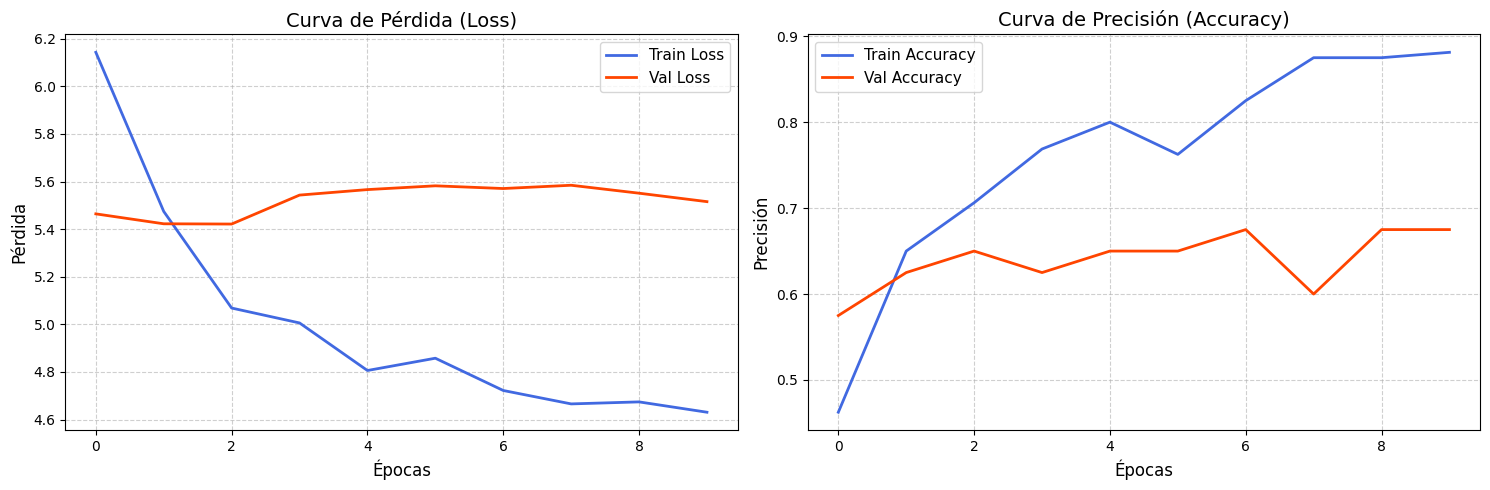

In [22]:
plot_loss(history)

In [23]:
# Extraer todas las imágenes y etiquetas reales del Dataset de validación de TensorFlow
y_true = []
y_pred_probs = []

for images, labels in val_ds:
    # Obtener probabilidades del modelo
    preds = model.predict(images, verbose=0)
    
    y_true.extend(labels.numpy())
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)

# Convertir las probabilidades (softmax) en la clase con el valor más alto (0, 1 o 2)
y_pred = np.argmax(y_pred_probs, axis=1)

print("¡Predicciones del set de validación calculadas con éxito!")

¡Predicciones del set de validación calculadas con éxito!


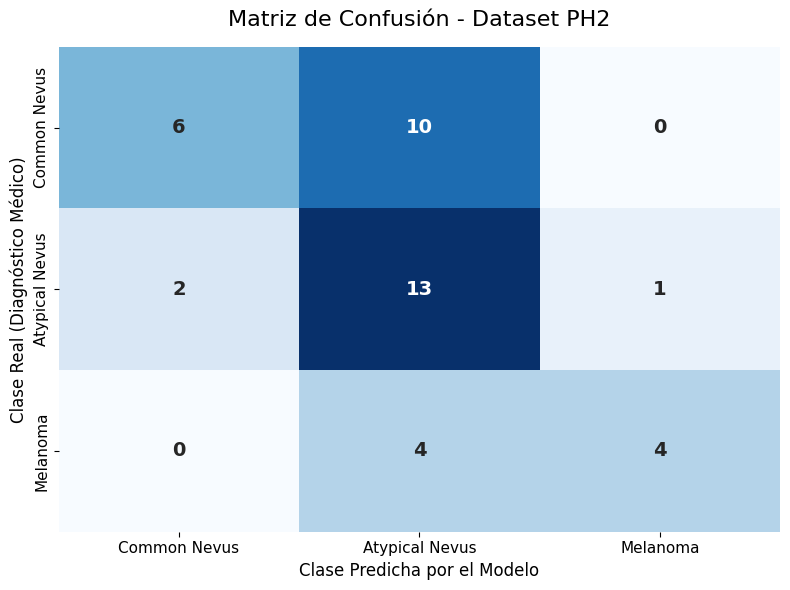

In [24]:
target_names = ['Common Nevus', 'Atypical Nevus', 'Melanoma']
plot_confusion_matriz(target_names, y_true, y_pred)

In [27]:
generate_report(target_names, y_true, y_pred)

         REPORTE DE CLASIFICACIÓN MULTICLASE (PH2)
                precision    recall  f1-score   support

  Common Nevus       0.75      0.38      0.50        16
Atypical Nevus       0.48      0.81      0.60        16
      Melanoma       0.80      0.50      0.62         8

      accuracy                           0.57        40
     macro avg       0.68      0.56      0.57        40
  weighted avg       0.65      0.57      0.56        40



## Tercera ejecucion

In [ ]:
K.clear_session()
gc.collect()
tf.compat.v1.reset_default_graph()
set_reproducibility(42)

In [28]:
# 1. Hacemos que TODO el modelo base sea entrenable
base_model = model.layers[2] # En la arquitectura funcional es la capa de ResNet
base_model.trainable = True

# 2. Recompilamos con un Learning Rate muy pequeño (1e-5 o 2e-5) 
# Si usas un LR alto aquí, destruirás los pesos preentrenados de ImageNet
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary() # Verás que ahora todos los millones de parámetros son entrenables

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,051 (91.99 MB)

 Trainable params: 14,976,003 (57.13 MB)

 Non-trainable params: 9,138,048 (34.86 MB)

In [29]:
callbacks_finetune = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,          # Más paciencia para el ajuste fino
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7
    )
]

In [30]:
print("Iniciando ajuste fino global de la red...")
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    class_weight=class_weights,
    callbacks=callbacks_finetune
)

Iniciando ajuste fino global de la red...
Epoch 1/40


I0000 00:00:1779055706.758191   16410 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_71704__.226


10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 504ms/step - accuracy: 0.6438 - loss: 5.4159 - val_accuracy: 0.6000 - val_loss: 5.4461 - learning_rate: 1.0000e-05
Epoch 2/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.6375 - loss: 5.2601 - val_accuracy: 0.6500 - val_loss: 5.4169 - learning_rate: 1.0000e-05
Epoch 3/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.6812 - loss: 5.3037 - val_accuracy: 0.6500 - val_loss: 5.4123 - learning_rate: 1.0000e-05
Epoch 4/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.6938 - loss: 5.1869 - val_accuracy: 0.6250 - val_loss: 5.4061 - learning_rate: 1.0000e-05
Epoch 5/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.7250 - loss: 5.1333 - val_accuracy: 0.6250 - val_loss: 5.3951 - learning_rate: 1.0000e-05
Epoch 6/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.6500 - loss: 5.2708 - val_accuracy: 0.6250 - val_loss: 5.3942 - learning_rate: 1.0000e-05
Epoch 7/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.6875 - loss: 5

In [31]:
# 1. Extraer nuevas predicciones
y_true = []
y_pred_probs = []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred = np.argmax(np.array(y_pred_probs), axis=1)

# 2. Imprimir reporte nuevo
print("="*60)
print("   NUEVO REPORTE DE CLASIFICACIÓN (DESPUÉS DE FINE-TUNING)")
print("="*60)
print(classification_report(y_true, y_pred, target_names=['Common Nevus', 'Atypical Nevus', 'Melanoma']))
print("="*60)

   NUEVO REPORTE DE CLASIFICACIÓN (DESPUÉS DE FINE-TUNING)
                precision    recall  f1-score   support

  Common Nevus       0.69      0.69      0.69        16
Atypical Nevus       0.59      0.62      0.61        16
      Melanoma       0.86      0.75      0.80         8

      accuracy                           0.68        40
     macro avg       0.71      0.69      0.70        40
  weighted avg       0.68      0.68      0.68        40



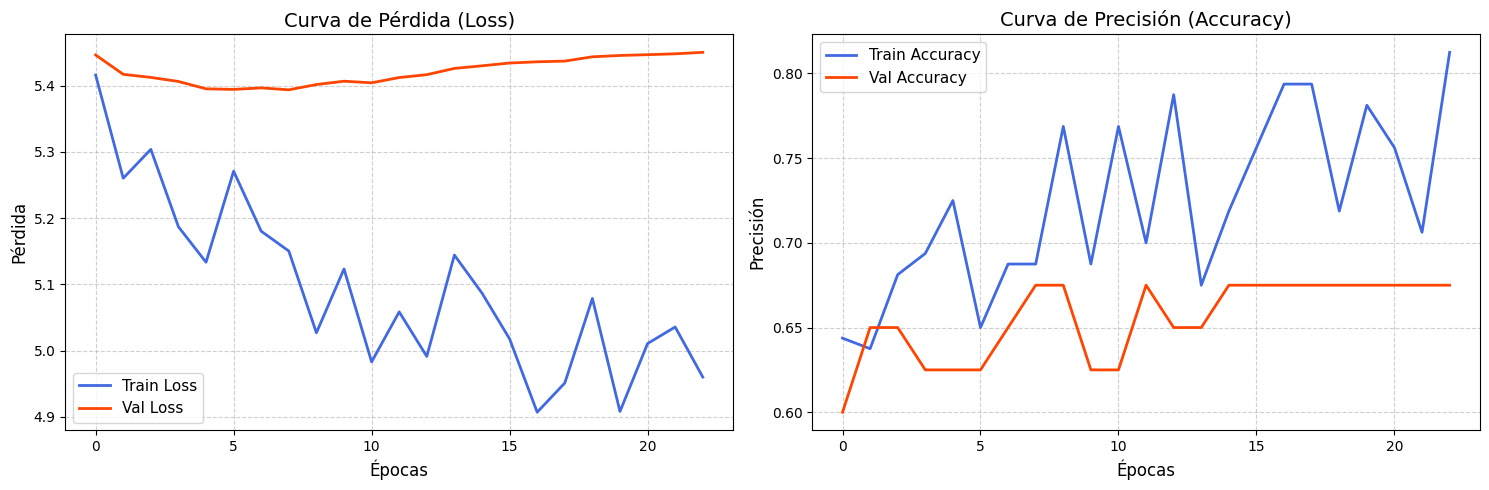

In [32]:
plot_loss(history_fine)

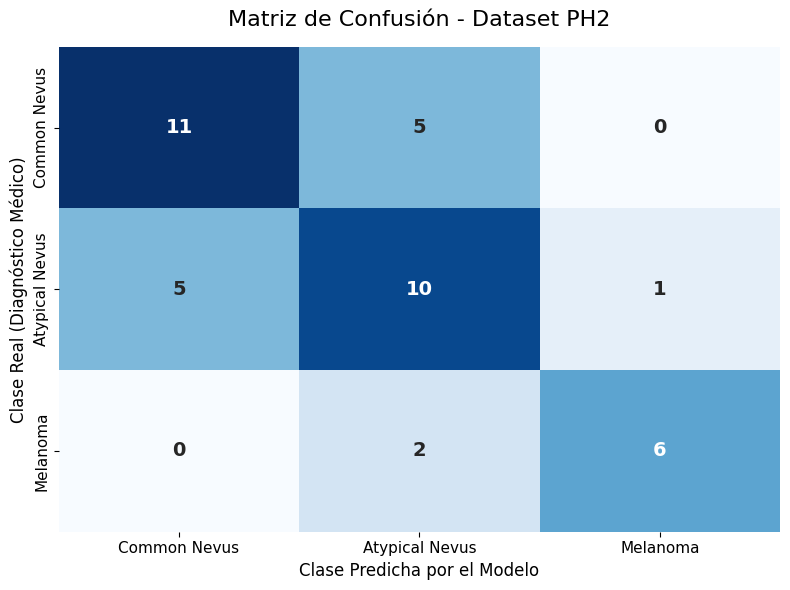

In [33]:
target_names = ['Common Nevus', 'Atypical Nevus', 'Melanoma']
plot_confusion_matriz(target_names, y_true, y_pred)

## Cuarta ejecucion

In [34]:
K.clear_session()
gc.collect()
tf.compat.v1.reset_default_graph()
set_reproducibility(42)

In [35]:
data_augmentation = tf.keras.Sequential([
    # Volteos idénticos (el lunar sigue siendo el mismo al revés)
    tf.keras.layers.RandomFlip("horizontal_and_vertical", seed=SEED),
    
    # Rotación completa (360 grados libres para que aprenda en cualquier ángulo)
    tf.keras.layers.RandomRotation(factor=1.0, fill_mode="reflect", seed=SEED),
    
    # Zoom variable (entre -10% y +10% de tamaño)
    tf.keras.layers.RandomZoom(height_factor=(-0.1, 0.1), width_factor=(-0.1, 0.1), fill_mode="reflect", seed=SEED),
    
    # Cambios de iluminación (Crucial para dermatología: simula flashes o sombras)
    tf.keras.layers.RandomBrightness(factor=0.2, value_range=(0.0, 255.0), seed=SEED),
    
    # Ajuste de contraste dinámico
    tf.keras.layers.RandomContrast(factor=0.2, seed=SEED)
])
print("[OK] Data Augmentation agresivo configurado.")

[OK] Data Augmentation agresivo configurado.


In [36]:
# 1. Regenerar los pipelines de tf.data aplicando el nuevo aumento de datos
train_ds = tf.data.Dataset.from_tensor_slices((train_files, train_labels)).map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = configure_for_performance(train_ds, shuffle=True, augment=True) # Aquí se inyecta el nuevo aumento

val_ds = tf.data.Dataset.from_tensor_slices((val_files, val_labels)).map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = configure_for_performance(val_ds, shuffle=False, augment=False)

# 2. Crear una ResNet50 limpia
model = create_medical_resnet()

# 3. Compilar (Empezamos con el learning rate base estable)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Modificar Callbacks: Le daremos un poco más de paciencia (12 épocas) 
# ya que con aumento de datos al modelo le cuesta un poco más memorizar al principio.
callbacks_agresivo = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-6)
]

In [37]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weights,
    callbacks=callbacks_agresivo
)

Epoch 1/50


I0000 00:00:1779056083.901826   16411 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_105478__.226


10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 511ms/step - accuracy: 0.5000 - loss: 5.8508 - val_accuracy: 0.5250 - val_loss: 5.6501 - learning_rate: 2.0000e-04
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.6313 - loss: 5.4175 - val_accuracy: 0.6000 - val_loss: 5.5159 - learning_rate: 2.0000e-04
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.6562 - loss: 5.3135 - val_accuracy: 0.6250 - val_loss: 5.4608 - learning_rate: 2.0000e-04
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.6500 - loss: 5.1266 - val_accuracy: 0.6250 - val_loss: 5.6395 - learning_rate: 2.0000e-04
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.7312 - loss: 5.0456 - val_accuracy: 0.6000 - val_loss: 6.2186 - learning_rate: 2.0000e-04
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.8125 - loss: 4.8297 - val_accuracy: 0.5500 - val_loss: 6.4150 - learning_rate: 2.0000e-04
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.7937 - loss: 4

In [38]:
# 1. Extraer predicciones
y_true = []
y_pred_probs = []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred = np.argmax(np.array(y_pred_probs), axis=1)

# 2. Imprimir reporte nuevo
print("="*60)
print("   REPORTE CON DATA AUGMENTATION AGRESIVO")
print("="*60)
print(classification_report(y_true, y_pred, target_names=['Common Nevus', 'Atypical Nevus', 'Melanoma']))
print("="*60)

   REPORTE CON DATA AUGMENTATION AGRESIVO
                precision    recall  f1-score   support

  Common Nevus       0.67      0.50      0.57        16
Atypical Nevus       0.52      0.75      0.62        16
      Melanoma       1.00      0.62      0.77         8

      accuracy                           0.62        40
     macro avg       0.73      0.62      0.65        40
  weighted avg       0.68      0.62      0.63        40



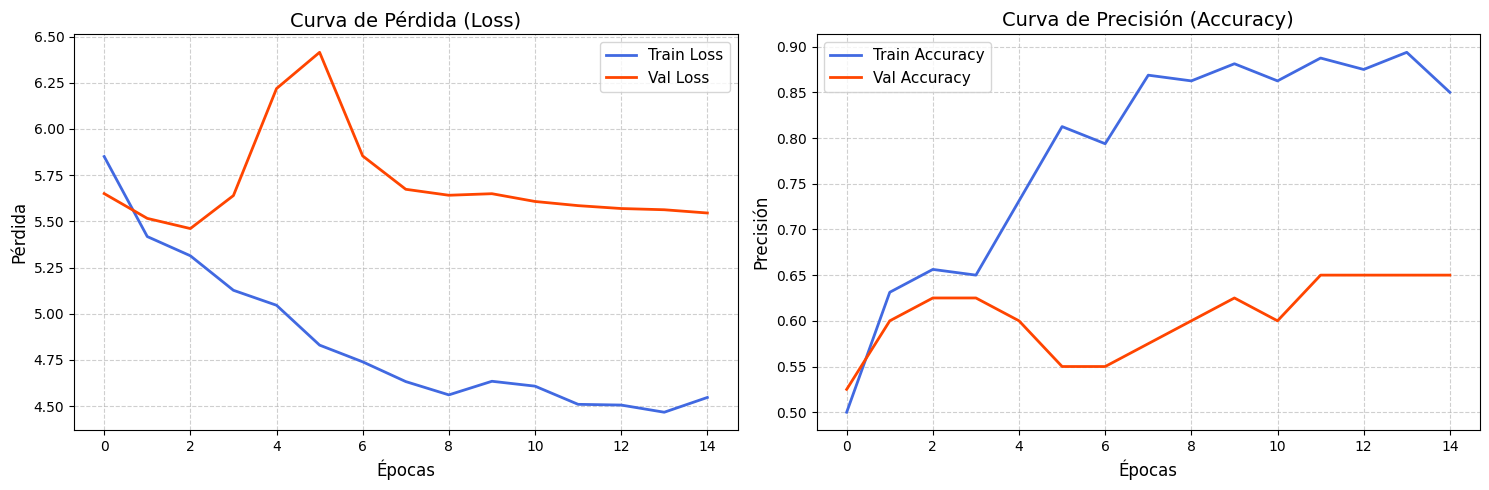

In [39]:
plot_loss(history)

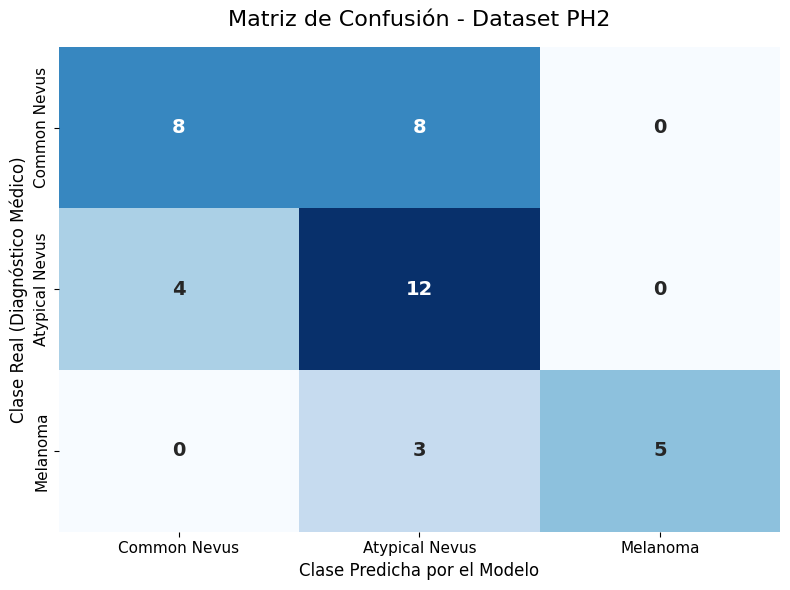

In [41]:
target_names = ['Common Nevus', 'Atypical Nevus', 'Melanoma']
plot_confusion_matriz(target_names, y_true, y_pred)

## MobileNet v2

### Primera ejecucion

In [42]:
K.clear_session()
gc.collect()
tf.compat.v1.reset_default_graph()
set_reproducibility(42)

In [43]:
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input

def create_medical_mobilenet(input_shape=(224, 224, 3), num_classes=3):
    inputs = layers.Input(shape=input_shape)
    
    # Preprocesamiento nativo para MobileNetV2
    x = layers.Lambda(preprocess_input)(inputs)
    
    # Cargar MobileNetV2 preentrenada en ImageNet
    base_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=input_shape)
    
    # Al ser una red pequeña, podemos congelar solo las primeras capas y dejar las últimas 40 libres desde el inicio
    base_model.trainable = True
    for layer in base_model.layers[:-40]:
        layer.trainable = False
        
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    
    # Clasificador ligero pero robusto (Bajamos la densidad para evitar overfitting)
    x = layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = layers.Dropout(0.4, seed=SEED)(x)
    
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs, outputs)
    return model

model = create_medical_mobilenet()

# Compilar con una tasa de aprendizaje estándar y controlada
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [44]:
# Mantenemos tus callbacks anteriores
callbacks_mobilenet = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-6)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weights,
    callbacks=callbacks_mobilenet
)

Epoch 1/50


I0000 00:00:1779056305.143201   16410 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_133102__.177
E0000 00:00:1779056306.070105   16410 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


10/10 ━━━━━━━━━━━━━━━━━━━━ 23s 845ms/step - accuracy: 0.4187 - loss: 3.4517 - val_accuracy: 0.5000 - val_loss: 3.4789 - learning_rate: 1.0000e-04
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5312 - loss: 3.2032 - val_accuracy: 0.4500 - val_loss: 3.6594 - learning_rate: 1.0000e-04
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6125 - loss: 3.0180 - val_accuracy: 0.4000 - val_loss: 4.0849 - learning_rate: 1.0000e-04
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6375 - loss: 3.0175 - val_accuracy: 0.4000 - val_loss: 4.3194 - learning_rate: 1.0000e-04
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6812 - loss: 2.9105 - val_accuracy: 0.4000 - val_loss: 4.4699 - learning_rate: 1.0000e-04
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7125 - loss: 2.7975 - val_accuracy: 0.4000 - val_loss: 4.5249 - learning_rate: 2.0000e-05
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7188 - loss: 2

In [45]:
y_true = []
y_pred_probs = []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred = np.argmax(np.array(y_pred_probs), axis=1)

print("="*60)
print("   REPORTE FINAL CON MOBILENET V2 + DATA AUGMENTATION")
print("="*60)
print(classification_report(y_true, y_pred, target_names=['Common Nevus', 'Atypical Nevus', 'Melanoma']))
print("="*60)

   REPORTE FINAL CON MOBILENET V2 + DATA AUGMENTATION
                precision    recall  f1-score   support

  Common Nevus       0.48      0.88      0.62        16
Atypical Nevus       0.50      0.25      0.33        16
      Melanoma       0.67      0.25      0.36         8

      accuracy                           0.50        40
     macro avg       0.55      0.46      0.44        40
  weighted avg       0.53      0.50      0.45        40



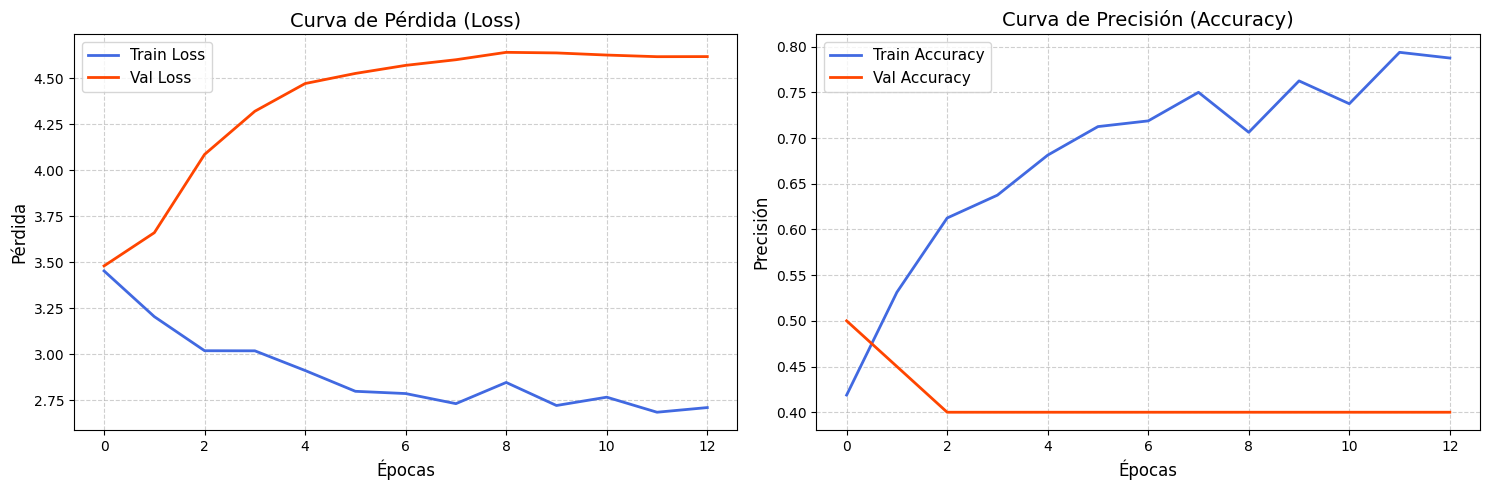

In [46]:
plot_loss(history)

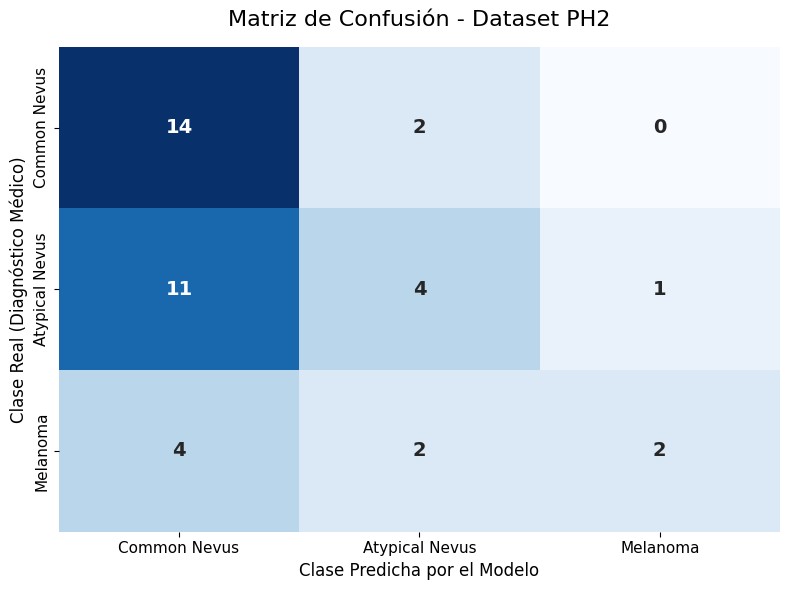

In [47]:
target_names = ['Common Nevus', 'Atypical Nevus', 'Melanoma']
plot_confusion_matriz(target_names, y_true, y_pred)

## Regularizando ResNet50

In [48]:
K.clear_session()
gc.collect()
tf.compat.v1.reset_default_graph()
set_reproducibility(42)

In [49]:
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras import layers, models
import tensorflow as tf

def create_constrained_resnet(input_shape=(224, 224, 3), num_classes=3):
    inputs = layers.Input(shape=input_shape)
    
    # Preprocesamiento nativo
    x = layers.Lambda(preprocess_input)(inputs)
    
    # Cargar ResNet50
    base_model = ResNet50(include_top=False, weights='imagenet', input_shape=input_shape)
    
    # CANDADO TOTAL: No permitimos que ninguna capa convolucional aprenda de memoria
    base_model.trainable = False
        
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    
    # Clasificador muy pequeño para evitar almacenamiento de memoria (Overfitting)
    x = layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.02))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.6, seed=SEED)(x) # Dropout sumamente agresivo
    
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs, outputs)
    return model

model = create_constrained_resnet()

# Compilamos con una tasa de aprendizaje estándar alta al inicio para que el clasificador se adapte rápido
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [50]:
callbacks_final = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-6)
]

history = model.fit(
    train_ds, # Mantiene el data augmentation agresivo activo
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weights,
    callbacks=callbacks_final
)

Epoch 1/50


I0000 00:00:1779056475.965728   16413 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_152914__.190


10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 476ms/step - accuracy: 0.3812 - loss: 3.9517 - val_accuracy: 0.4000 - val_loss: 3.7101 - learning_rate: 0.0010
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5312 - loss: 3.2792 - val_accuracy: 0.4750 - val_loss: 3.3783 - learning_rate: 0.0010
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.5437 - loss: 3.0452 - val_accuracy: 0.5500 - val_loss: 3.2350 - learning_rate: 0.0010
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.5500 - loss: 2.7597 - val_accuracy: 0.5500 - val_loss: 3.1153 - learning_rate: 0.0010
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.6062 - loss: 2.5535 - val_accuracy: 0.5250 - val_loss: 2.9130 - learning_rate: 0.0010
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.6500 - loss: 2.4406 - val_accuracy: 0.5000 - val_loss: 2.9236 - learning_rate: 0.0010
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.5688 - loss: 2.3918 - val_accuracy: 0.

In [51]:
y_true = []
y_pred_probs = []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred = np.argmax(np.array(y_pred_probs), axis=1)

print("="*60)
print("   REPORTE DE ESTABILIZACIÓN CON RESNET50")
print("="*60)
print(classification_report(y_true, y_pred, target_names=['Common Nevus', 'Atypical Nevus', 'Melanoma']))
print("="*60)

   REPORTE DE ESTABILIZACIÓN CON RESNET50
                precision    recall  f1-score   support

  Common Nevus       0.75      0.38      0.50        16
Atypical Nevus       0.52      0.75      0.62        16
      Melanoma       0.67      0.75      0.71         8

      accuracy                           0.60        40
     macro avg       0.65      0.62      0.61        40
  weighted avg       0.64      0.60      0.59        40



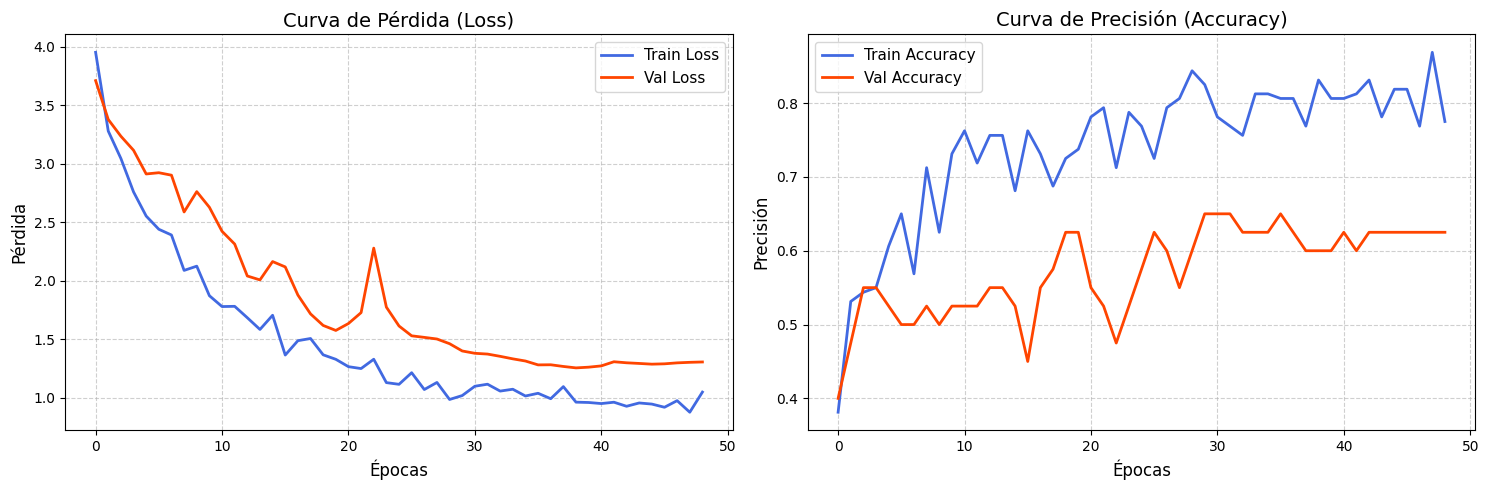

In [52]:
plot_loss(history)

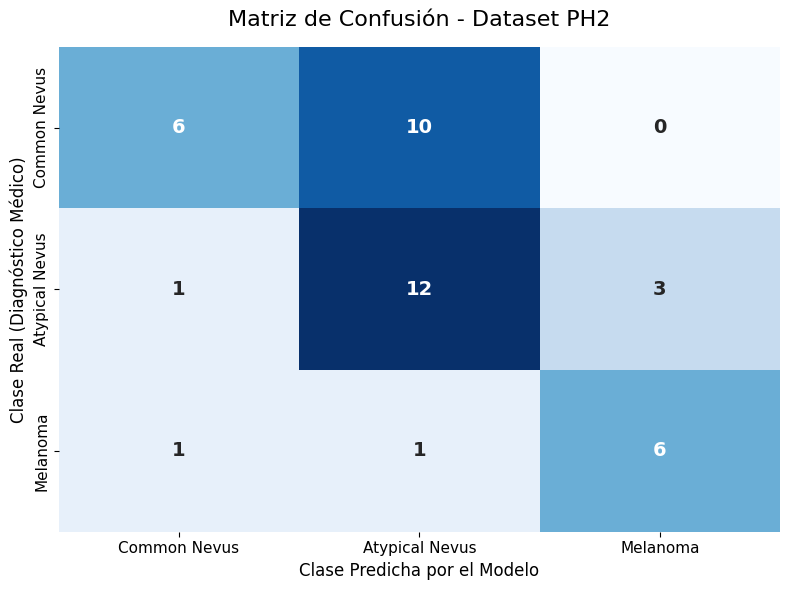

In [53]:
target_names = ['Common Nevus', 'Atypical Nevus', 'Melanoma']
plot_confusion_matriz(target_names, y_true, y_pred)

In [55]:
import cv2

def predict_lesion(image_path, model):
    # 1. Cargar la imagen con OpenCV
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: No se pudo cargar la imagen en la ruta: {image_path}")
        return
    
    # Convertir de BGR (OpenCV) a RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 2. Preprocesar para el modelo (Resize a 224x224)
    img_resized = cv2.resize(img_rgb, (224, 224))
    img_array = np.expand_dims(img_resized, axis=0) # Añadir dimensión de batch (1, 224, 224, 3)
    
    # 3. Realizar la predicción
    preds = model.predict(img_array, verbose=0)[0]
    classes = ['Common Nevus', 'Atypical Nevus', 'Melanoma']
    
    # 4. Mostrar resultados gráficos
    plt.figure(figsize=(5, 5))
    plt.imshow(img_rgb)
    plt.axis('off')
    
    print("\n" + "="*40)
    print("      DIAGNÓSTICO DEL MODELO AI")
    print("="*40)
    for i, class_name in enumerate(classes):
        print(f" - {class_name}: {preds[i]*100:.2f}%")
    print("="*40)
    
    clase_ganadora = classes[np.argmax(preds)]
    print(f"Predicción Final: ¡{clase_ganadora.upper()}!")
    plt.show()



      DIAGNÓSTICO DEL MODELO AI
 - Common Nevus: 31.37%
 - Atypical Nevus: 68.33%
 - Melanoma: 0.29%
Predicción Final: ¡ATYPICAL NEVUS!


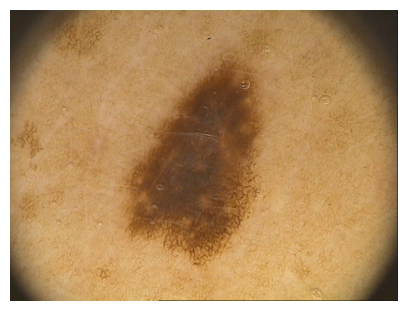

In [56]:
ruta_prueba = filepaths[150] 
predict_lesion(ruta_prueba, model)

## Agregando ruido

In [64]:
K.clear_session()
gc.collect()
tf.compat.v1.reset_default_graph()
set_reproducibility(42)

In [65]:
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras import layers, models

def create_ultra_stable_resnet(input_shape=(224, 224, 3), num_classes=3):
    inputs = layers.Input(shape=input_shape)
    
    # Preprocesamiento nativo
    x = layers.Lambda(preprocess_input)(inputs)
    
    # Cargar ResNet50 totalmente congelada (Evita memorización en capas convolucionales)
    base_model = ResNet50(include_top=False, weights='imagenet', input_shape=input_shape)
    base_model.trainable = False
    x = base_model(x, training=False)
    
    # Reducción espacial
    x = layers.GlobalAveragePooling2D()(x)
    
    # FILTRO 1: Dropout inicial alto para romper correlaciones de pixeles
    x = layers.Dropout(0.5, seed=SEED)(x)
    
    # Capa densa pequeña (64 neuronas) con penalización L2 muy alta (0.08)
    # Esto impide físicamente que las neuronas tengan valores grandes o específicos
    x = layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.08))(x)
    x = layers.BatchNormalization()(x)
    
    # FILTRO 2: Dropout final extremo (Apaga aleatoriamente el 65% de las neuronas en cada paso)
    x = layers.Dropout(0.65, seed=SEED)(x)
    
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs, outputs)
    return model

# Re-instanciar el modelo con los candados físicos activados
model = create_ultra_stable_resnet()

# Compilar estable
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [66]:
# Subimos un poco la paciencia para dejar que el suavizado de etiquetas haga efecto
callbacks_ultra = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-6)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weights,
    callbacks=callbacks_ultra
)

Epoch 1/50


I0000 00:00:1779057027.978024   16414 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_255794__.191


10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 468ms/step - accuracy: 0.2250 - loss: 11.4691 - val_accuracy: 0.3750 - val_loss: 9.3717 - learning_rate: 0.0010
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.3875 - loss: 9.3678 - val_accuracy: 0.4500 - val_loss: 8.3731 - learning_rate: 0.0010
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.4437 - loss: 8.5424 - val_accuracy: 0.5000 - val_loss: 7.7214 - learning_rate: 0.0010
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.4750 - loss: 7.3882 - val_accuracy: 0.5250 - val_loss: 6.9860 - learning_rate: 0.0010
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.4812 - loss: 6.9075 - val_accuracy: 0.5250 - val_loss: 6.2334 - learning_rate: 0.0010
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.4812 - loss: 6.2156 - val_accuracy: 0.5500 - val_loss: 5.5565 - learning_rate: 0.0010
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.4750 - loss: 5.7437 - val_accuracy: 0

In [67]:
y_true = []
y_pred_probs = []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred = np.argmax(np.array(y_pred_probs), axis=1)

print("="*60)
print("   REPORTE: ANTI-OVERFITTING EXTREMO")
print("="*60)
print(classification_report(y_true, y_pred, target_names=['Common Nevus', 'Atypical Nevus', 'Melanoma']))
print("="*60)

   REPORTE: ANTI-OVERFITTING EXTREMO
                precision    recall  f1-score   support

  Common Nevus       0.80      0.50      0.62        16
Atypical Nevus       0.64      0.88      0.74        16
      Melanoma       0.88      0.88      0.88         8

      accuracy                           0.72        40
     macro avg       0.77      0.75      0.74        40
  weighted avg       0.75      0.72      0.72        40



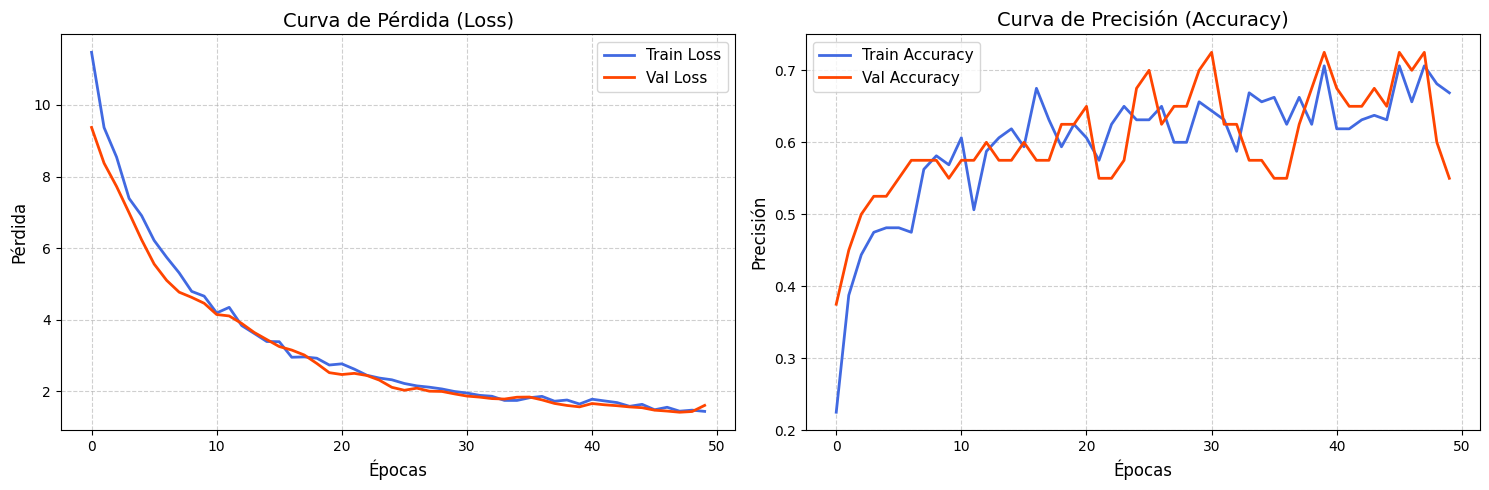

In [68]:
plot_loss(history)

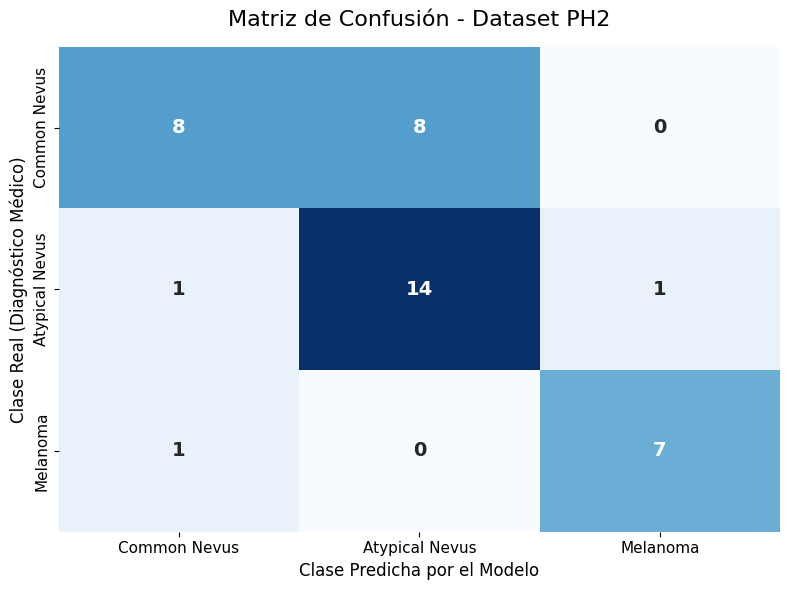

In [69]:
target_names = ['Common Nevus', 'Atypical Nevus', 'Melanoma']
plot_confusion_matriz(target_names, y_true, y_pred)

In [70]:
# Guardamos el modelo con mejor capacidad de generalización
model.save("mejor_modelo_melanoma_resnet50.keras")
print("¡Felicidades! Tu modelo estable contra el sobreajuste ha sido guardado exitosamente.")

¡Felicidades! Tu modelo estable contra el sobreajuste ha sido guardado exitosamente.
